In [55]:
# import Librairies
import pandas as pd 
import matplotlib.pyplot as plt

# Data & Clean
df = pd.read_csv(r'C:\Users\PC\Documents\Learning_PYTHON\data_jobs.csv')
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)

# In this part , You learn how to use the Apply() fonction 

In [56]:
# Intoduction:
# We will calcaulate the salary of the next year with inflation of 3%
df_salary = df[df['salary_year_avg'].notna()].copy()

def projected_salary(salary) : 
    return salary * 1.03

df_salary['projected_salary'] = df_salary['salary_year_avg'].apply(projected_salary)  # apply (fonction)

df_salary [ ['salary_year_avg' , 'projected_salary']]

,salary_year_avg,projected_salary
28,109500.0,112785.00
77,140000.0,144200.00
92,120000.0,123600.00
100,228222.0,235068.66
109,89000.0,91670.00
...,...,...
785624,139216.0,143392.48
785641,150000.0,154500.00
785648,221875.0,228531.25
785682,157500.0,162225.00


In [57]:
# Main caise :
# We will anylyse the demand of the skills in 'job skills' column
# To make analytics about thise column , it should be with a 'List' type . But its a 'Str' . You can confirme it using df.info()
# ' import ast' and using    " ast.literal_eval ( df['job_skills']) "  fontion , can help us transforming the type into list

import ast
type ( ast.literal_eval(df['job_skills'][1]) )     #You see its a list now 

# Your turn to do this for all the columns 

list

In [58]:
import ast 

def To_List (skill) :
    if pd.notna(skill) :
       return ast.literal_eval (skill)

df['job_skills'] = df['job_skills'].apply(To_List)

In [59]:
type (df['job_skills'][2])    # You dit it !

list

In [60]:
# df['job_skills'].apply ( lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list )
# This if you wanna use a lambda and not a fonction 

In [ ]:
# if you want to use apply() on rows use this :    df.apply ( fontion , axis =1 )

<Axes: xlabel='job_skills'>

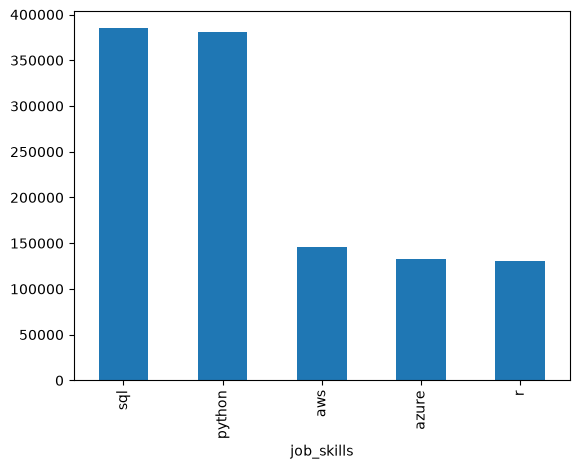

In [ ]:
# Now Let's Visualase it 
# we need to count how mush the skill is repeated . But as you see they are many skils in 1 row . to solve that we will use explode() methode

df['job_skills'].explode().value_counts().head().plot(kind='bar')